Para realizar una regresión lineal múltiple, primero necesitamos importar la base de datos llamada `Nasa.csv`. Para ello utilizamos la librería `pandas`, que nos permite leer el archivo y guardar su contenido en una variable.
Una vez guardado, usamos la función `shape` de pandas para conocer las dimensiones del archivo (número de filas y columnas). Finalmente, mostramos las primeras 15 filas con el fin de visualizar algunos de los datos que contiene la base de datos.

In [18]:
import pandas as pd
data = pd.read_csv("NASA.csv")
print("Dimensiones de el archivo de datos:",data.shape)
print()
print("Primeras 15 filas de archivo de datos")
print(data.head(15))

Dimensiones de el archivo de datos: (1503, 6)

Primeras 15 filas de archivo de datos
    frecuencia  angulo  longitud  velocidad   espesor  presion
0          800     0.0    0.3048       71.3  0.002663  126.201
1         1000     0.0    0.3048       71.3  0.002663  125.201
2         1250     0.0    0.3048       71.3  0.002663  125.951
3         1600     0.0    0.3048       71.3  0.002663  127.591
4         2000     0.0    0.3048       71.3  0.002663  127.461
5         2500     0.0    0.3048       71.3  0.002663  125.571
6         3150     0.0    0.3048       71.3  0.002663  125.201
7         4000     0.0    0.3048       71.3  0.002663  123.061
8         5000     0.0    0.3048       71.3  0.002663  121.301
9         6300     0.0    0.3048       71.3  0.002663  119.541
10        8000     0.0    0.3048       71.3  0.002663  117.151
11       10000     0.0    0.3048       71.3  0.002663  115.391
12       12500     0.0    0.3048       71.3  0.002663  112.241
13       16000     0.0    0.3048 

Una parte fundamental del proceso de regresión lineal múltiple es separar los datos en entrenamiento y prueba. Para este caso, se utilizará una proporción de 70% para entrenamiento y 30% para prueba, seleccionando las observaciones de manera aleatoria.
Esto se logra con la función `sample()`, que permite tomar aleatoriamente el 70% de los datos y asignarlos a la variable de entrenamiento; los datos restantes se guardan en la variable de prueba.
Finalmente, para comprobar que no se perdió información durante la separación, se suman las filas de ambas variables. El resultado debe ser 1503, que corresponde al total de datos originales.

In [24]:
data_train = data.sample(frac = 0.7)
data_valid = data.drop(data_train.index)
print("Datos de entranamiento:", data_train.shape)
print("Datos de prueba:", data_valid.shape)

if data_train.shape[0] + data_valid.shape[0] == data.shape[0]:
    print("Los datos están separados correctamente. Resultado de la suma:", data_train.shape[0] + data_valid.shape[0])
else:
    print("Los datos no están separados correctamente. Resultado de la suma:", data_train.shape[0] + data_valid.shape[0])

Datos de entranamiento: (1052, 6)
Datos de prueba: (451, 6)
Los datos están separados correctamente. Resultado de la suma: 1503


El siguiente paso consiste en entrenar el modelo de regresión. El objetivo es que el modelo pueda predecir la presión sonora utilizando como variables independientes las primeras cinco columnas de la base de datos: frecuencia, ángulo, longitud, velocidad y espesor.
Para simplificar este procedimiento, se emplea la librería `statsmodels.api`, específicamente la función `OLS()`, que nos permite construir el modelo de regresión lineal. Posteriormente, el modelo se ajusta con la función `fit()`, y finalmente se imprime un resumen estadístico, que incluye entre otros valores los p-values de cada variable.

In [25]:
import statsmodels.api as sm
X = data_train.drop('presion', axis = 1)
Y = data_train.presion
model = sm.OLS(Y,sm.add_constant(X))
results = model.fit()
print(results.summary())
print(results.pvalues)
print(results.f_pvalue)

                            OLS Regression Results                            
Dep. Variable:                presion   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     229.7
Date:                Wed, 20 Aug 2025   Prob (F-statistic):          1.65e-165
Time:                        12:23:49   Log-Likelihood:                -3139.9
No. Observations:                1052   AIC:                             6292.
Df Residuals:                    1046   BIC:                             6322.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.5800      0.648    204.649      0.0

A partir de los resultados del análisis de regresión lineal múltiple, primero se considera la prueba de la distribución F. El estadístico F obtenido es 220.0 con un valor p aproximado de 2.93x10^-159, el cual es muy inferior al nivel de significancia de 0.05. Esto permite rechazar la hipótesis nula y concluir que el modelo al menos una de las variables independientes tiene un efecto sobre la presión.

Posteriormente, se analizan las pruebas t individuales para cada variable independiente. Los resultados muestran que todas las variables —frecuencia, ángulo, longitud, velocidad y espesor— tienen valores p menores a 0.05, lo que indica que cada una de ellas presenta una asociación significativa con la presión.

Finalmente, al comparar la magnitud de los estadísticos t, se identifica que la variable espesor es la más influyente en el modelo, debido a a la magnitud de su valor t, lo que evidencia un efecto más fuerte sobre la presión en comparación con las demás variables.

In [26]:
print("A partir de los resultados del análisis de regresión lineal múltiple, primero se considera la prueba de la distribución F. El estadístico F obtenido es 220.0 con un valor p aproximado de 2.93x10^-159, el cual es muy inferior al nivel de significancia de 0.05. Esto permite rechazar la hipótesis nula y concluir que el modelo al menos una de las variables independientes tiene un efecto sobre la presión.")
print("")
print("Posteriormente, se analizan las pruebas t individuales para cada variable independiente. Los resultados muestran que todas las variables —frecuencia, ángulo, longitud, velocidad y espesor— tienen valores p menores a 0.05, lo que indica que cada una de ellas presenta una asociación significativa con la presión.")
print("")
t_values = results.tvalues.drop("const")
influyente = t_values.abs().idxmax()
print("Finalmente, al comparar la magnitud de los estadísticos t, se identifica que la variable", influyente, "es la más influyente en el modelo, debido a a la magnitud de su valor t, lo que evidencia un efecto más fuerte sobre la presión en comparación con las demás variables.")

A partir de los resultados del análisis de regresión lineal múltiple, primero se considera la prueba de la distribución F. El estadístico F obtenido es 220.0 con un valor p aproximado de 2.93x10^-159, el cual es muy inferior al nivel de significancia de 0.05. Esto permite rechazar la hipótesis nula y concluir que el modelo al menos una de las variables independientes tiene un efecto sobre la presión.

Posteriormente, se analizan las pruebas t individuales para cada variable independiente. Los resultados muestran que todas las variables —frecuencia, ángulo, longitud, velocidad y espesor— tienen valores p menores a 0.05, lo que indica que cada una de ellas presenta una asociación significativa con la presión.

Finalmente, al comparar la magnitud de los estadísticos t, se identifica que la variable frecuencia es la más influyente en el modelo, debido a a la magnitud de su valor t, lo que evidencia un efecto más fuerte sobre la presión en comparación con las demás variables.


Para evaluar la calidad del modelo utilizaremos dos métricas: el Error Estándar Residual ($RSE$) y el coeficiente de determinación ($R^2$), tanto en el conjunto de entrenamiento como en el de prueba.

En los datos de entrenamiento:

* El RSE se obtiene aplicando la raíz cuadrada a la métrica `scale` del modelo. Para esto se emplea la librería `numpy`.

* El valor de $R^2$ se obtiene directamente del objeto de resultados ajustado).

En los datos de prueba:
* No contamos con un valor calculado automáticamente, por lo que es necesario aplicar las fórmulas de $RSE$ $R^2$ de manera manual a partir de las predicciones y los valores reales. Las formulas son la siguientes:

$RSE = \sqrt{\frac{\sum_{i=1}^{n}(y_{i}-\hat{y})^2}{n-m-1}}$

$R^2 = 1-\frac{\sum_{i=1}^{n}(y_{i}-\hat{y})^2}{\sum_{i=1}^{n}(y_i-\overline{y})^2}$

In [29]:
import numpy as np
n = X.shape[0]
m = X.shape[1]
# Entrenamiento
RSETrain = np.sqrt(results.scale)
R2Train = results.rsquared
print("RSE de entrenamiento =",RSETrain)
print("R^2 de entrenamiento=", R2Train)
# Validacion
XValid = data_valid.drop('presion', axis = 1)
YhatValid = results.predict(sm.add_constant(XValid))
YValid = data_valid.presion
RSSValid = sum((YValid - YhatValid)**2)
TSSValid = sum((YValid-np.mean(YValid))**2)
nValid = XValid.shape[0]
mValid = XValid.shape[1]
RSEValid = np.sqrt(RSSValid/(n-m-1))
R2Valid = 1-RSSValid/TSSValid
print("RSE de prueba=",RSEValid)
print("R^2 de prueba=", R2Valid)

RSE de entrenamiento = 4.799995119399138
R^2 de entrenamiento= 0.5233806961960432
RSE de prueba= 3.1762362669287594
R^2 de prueba= 0.4947814805354843


A continuación, se graficará el modelo frente a sus predicciones para verificar qué tan bien describe las observaciones reales. Para ello, se genera una gráfica de dispersión donde en el eje X se representan los valores reales de la presión sonora, mientras que en el eje Y se muestran los valores estimados por el modelo. En un escenario de predicción perfecta, los puntos deberían alinearse sobre la recta ideal $y=x$, la cual forma un ángulo de 45° con respecto al eje X.

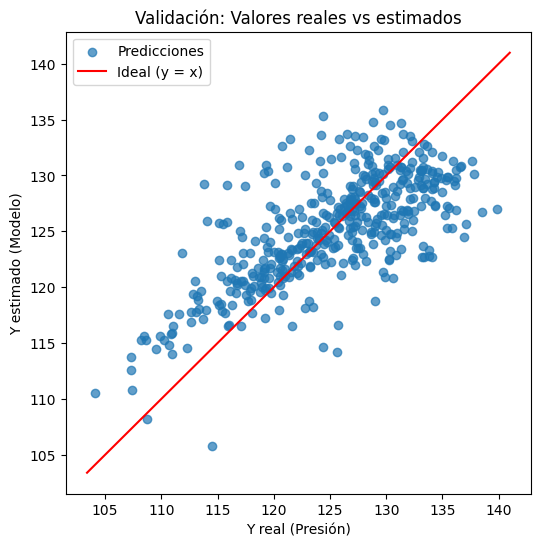

Angulo de la recta: 26.631168037649424


In [38]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(6,6))
plt.scatter(YValid, YhatValid, alpha=0.7, label="Predicciones")
plt.plot([Y.min(), Y.max()],
         [Y.min(), Y.max()],
         color="red", label="Ideal (y = x)")
plt.xlabel("Y real (Presión)")
plt.ylabel("Y estimado (Modelo)")
plt.title("Validación: Valores reales vs estimados")
plt.legend()
plt.show()

model = LinearRegression().fit(YValid.values.reshape(-1, 1), YhatValid)
angulo_deg = np.arctan(model.coef_[0]) *180/np.pi
print("Angulo de la recta:", angulo_deg)

El ángulo de la recta obtenida es de 26.63°, lo cual se aproxima, a los 45° ideales que representarían un ajuste perfecto. Esto indica que el modelo desarrollado no alcanza un nivel de predicción óptimo, pero tampoco puede considerarse deficiente. Esta conclusión es consistente con el valor de $R^2 = 0.49$, el cual refleja que el modelo explica aproximadamente la mitad de la variabilidad de los datos, un desempeño moderado en comparación con lo esperado.